### 1. Dependencies

In [191]:
import numpy as np
import pandas as pd
from itertools import chain
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


#functions
from functions.functions import low_high, set_first_row_to_zero
from functions.portfolio_strategy.univariate_sorting_preprocess import prepare_univariate_sorting_inputs
from functions.data_functions.get_data import get_row_universe, get_usa_universe, get_processed_fx_rates, get_famafrench_factors, get_processed_index
from functions.data_functions.process_data import process_row_universe, process_usa_universe, process_global_universe

In [192]:
# MANUAL INPUT
download_wrds_data = False#True
download_ff_data = False#True
esg_choice = 'none'               # 's&p' or 'refinitiv' or 'none'
start_year = 2013                 # these ESG sources are aligned for `start_year==2013`
end_year = 2024

#sector split
top_x_by_industry_even_split = 12

#Univariate Sorting
no_simple_quantiles = 6

# Thresholds
# default: alpha_bound = 0.05
alpha_bound = 0.1    # percentage of extremes to exclude from the GOLDEN data
mktcap_covered = 0.95 # target market cap coverage per currency area # Filters bottom 5% of market cap

Golden Data

In [234]:
#Golden Dataset Location
golden_location = "C:/Users/chris/Documents/GitHub/data/Golden_Data"

# Golden Dataset
#lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2A.csv')
#lc = pd.read_csv(f'{golden_location}/LC_dataset_v_2B1_20260409.csv')

# #3d counts
lc_3d  = pd.read_parquet(f"{golden_location}/LC_dataset_v_2A_3d_counts_gen2.parquet")
company_data = pd.read_parquet("./data/company_database_20260414.parquet")


#Preprocessing for merging
cols_to_merge = ['loc', 'MacroRegion', 'GICS_level_1', 'GICS_level_2', 'GICS_level_3', 'gvkey']
company_data = company_data.dropna(subset=["gvkey"])
lc_3d = lc_3d.dropna(subset=["gvkey"])
company_data["gvkey"] = company_data["gvkey"].astype("Int64").astype("string")
lc_3d['gvkey'] = lc_3d['gvkey'].astype(int).astype(str)



company_dim = company_data[cols_to_merge].drop_duplicates(subset=["gvkey"])
lc = lc_3d.merge(company_dim, on="gvkey", how="left", validate="m:1")


In [235]:
lc_3d.shape

(78662, 1692)

In [236]:
lc.shape

(78662, 1697)

In [238]:
company_data.loc[company_data["gvkey"].astype("Int64").astype("string") == "144009", cols_to_merge]

,loc,MacroRegion,GICS_level_1,GICS_level_2,GICS_level_3,gvkey
4213,GBR,Europe,Financials,Insurance,Insurance,144009
19055,GBR,Europe,Financials,Insurance,Insurance,144009
51424,GBR,Europe,Financials,Insurance,Insurance,144009


Filters

In [239]:
#currencies we keep
currency_filter = ['EUR', 'USD'] #['CHF', 'GBP', 'EUR', 'USD'])]
# region_filter = ["United States and Canada"]

execute_location_filters = False
loc_filter = ["USA"]

drop_real_estate = True


### 2. Data

#### 2.1 LC dataset

In [240]:
from functions.data_functions.process_lc import process_lc, map_sectors, filter_sum_activities_by_fiscal_year_quantiles

lc = process_lc(lc, start_year, end_year)


if drop_real_estate:
    lc = lc[lc['GICS_level_1'] != 'Real Estate']

#print(lc['GICS_level_1'].unique())
lc['Industry'] = lc['GICS_level_1'].apply(map_sectors)
print("Industries:", lc['Industry'].unique())


# # Filter to keep a stable panel meaning we have initiatives for all years
# gvkey_stable_panel = lc.groupby(['gvkey'])['gvkey'].count() == (lc['rfyear'].max()-lc['rfyear'].min()+1)
# gvkey_stable_panel = gvkey_stable_panel[gvkey_stable_panel].index
# lc = lc[lc['gvkey'].isin(gvkey_stable_panel)]


#FILTER for LC dataset
if execute_location_filters == True:
    lc = lc[lc['loc'].isin(loc_filter)]

# lc = lc[lc["Industry"] == "ICT"]


Industries: ['Health Care' 'Financial' 'Utilities' 'ICT' 'Primary Industries'
 'Industrials' 'Consumer']


In [241]:
'''
Dictionary specifying types categories

Stakeholders:
  - customers
  - employees
  - enviroment
  - local communities and society
  - nothing
  - shareholders
  - suppliers
'''

# Actions
categories_dict_actions = {
  'advocacy, preparation, transformation':
    {
      # 'TYPE: association': 0, 
      # 'TYPE: pricing': 2,                                                             # For our universe, these are usually discounts to disadvantaged customers
      'TYPE: donation & funding': 0, 
      'TYPE: volunteerism': 0, 
      'TYPE_SREC: communication - local communities and society': 0, 
      'TYPE_SREC: training - local communities and society': 0,                       # For our universe, these are usually akin to volunteering activities
      'TYPE_SREC: incentives - local communities and society': 0,                     # For our universe, these are usually `donation & funding` through vouchers etc.
      'TYPE_SREC: organizational structuring - local communities and society': 0, 

      'TYPE: adoption of standards and rules': 1, 
      'TYPE: assessment and measurement': 1,                                          # For our universe, these are mostly partnerships (e.g., with ONGs) for enviromental/social impact assessments
      'TYPE_SREC: communication - employees': 1, 
      'TYPE_SREC: training - employees': 1, 
      'TYPE_SREC: incentives - employees': 1, 
      'TYPE_SREC: organizational structuring - employees': 1, 

      'TYPE: asset modification': 2,
      'TYPE: modification of procedures': 2, 
      'TYPE: new products': 2, 
      'TYPE: r&d investments': 2, 
      'TYPE_SREC: communication - customers': 2, 
      'TYPE_SREC: communication - shareholders': 2, 
      'TYPE_SREC: communication - suppliers': 2, 
      'TYPE_SREC: training - customers': 2, 
      'TYPE_SREC: training - shareholders': 2, 
      'TYPE_SREC: training - suppliers': 2, 
      'TYPE_SREC: incentives - customers': 2, 
      'TYPE_SREC: incentives - shareholders': 2, 
      'TYPE_SREC: incentives - suppliers': 2, 
      'TYPE_SREC: organizational structuring - customers': 2, 
      'TYPE_SREC: organizational structuring - shareholders': 2, 
      'TYPE_SREC: organizational structuring - suppliers': 2, 
  },
}

# MANUAL INPUT
# Choose which action characterization to use
categories_dict_actions = categories_dict_actions['advocacy, preparation, transformation']

In [248]:

# People vs Planet SDGs
categories_dict_sdgs = {
  'SDG: 1': 0,
  'SDG: 2': 0,
  'SDG: 3': 0,
  'SDG: 4': 0,
  'SDG: 5': 0,
  'SDG: 8': 0,
  'SDG: 10': 0,
  'SDG: 6': 1,
  'SDG: 7': 1,
  'SDG: 12': 1,
  'SDG: 13': 1,
  'SDG: 14': 1,
  'SDG: 15': 1
}

# Initialise dictionary
categories_dict_people = {}
categories_dict_planet = {}

# Initialise other dictionaries
categories_dict_people_advocacy = {}
categories_dict_planet_advocacy = {}

# Loop over actions
for key_action, value_action in categories_dict_actions.items():

    # Loop over sdgs
    for key_sdg, value_sdg in categories_dict_sdgs.items():
        
        # Planet-related activities
        if value_sdg == 1:
            print(key_action)
            categories_dict_planet[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = value_action
            categories_dict_planet_advocacy[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = 2-value_action
            
        else:
            categories_dict_people[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = value_action
            categories_dict_people_advocacy[f'{key_action.replace("TYPE: ", "").lower()} - {key_sdg.replace(":", "")}'] = 2-value_action


TYPE: donation & funding
TYPE: donation & funding
TYPE: donation & funding
TYPE: donation & funding
TYPE: donation & funding
TYPE: donation & funding
TYPE: volunteerism
TYPE: volunteerism
TYPE: volunteerism
TYPE: volunteerism
TYPE: volunteerism
TYPE: volunteerism
TYPE_SREC: communication - local communities and society
TYPE_SREC: communication - local communities and society
TYPE_SREC: communication - local communities and society
TYPE_SREC: communication - local communities and society
TYPE_SREC: communication - local communities and society
TYPE_SREC: communication - local communities and society
TYPE_SREC: training - local communities and society
TYPE_SREC: training - local communities and society
TYPE_SREC: training - local communities and society
TYPE_SREC: training - local communities and society
TYPE_SREC: training - local communities and society
TYPE_SREC: training - local communities and society
TYPE_SREC: incentives - local communities and society
TYPE_SREC: incentives - loca

In [243]:
# MANUAL INPUT
#change below to the above sdg - evn and non env>


#
categories_dict = categories_dict_planet    # Can be: categories_dict_actions (Default), categories_dict_people, categories_dict_planet

In [252]:
lc.columns.tolist()

['pdf_local_path',
 'id',
 'initiative_description_with_context',
 'initiative_description_processed',
 'stakeholder_beneficiary',
 'predicted_report_year',
 'modification of procedures - SDG 1 - customers',
 'modification of procedures - SDG 1 - employees',
 'modification of procedures - SDG 1 - environment',
 'modification of procedures - SDG 1 - local communities and society',
 'modification of procedures - SDG 1 - nothing',
 'modification of procedures - SDG 1 - shareholders',
 'modification of procedures - SDG 1 - suppliers',
 'modification of procedures - SDG 2 - customers',
 'modification of procedures - SDG 2 - employees',
 'modification of procedures - SDG 2 - environment',
 'modification of procedures - SDG 2 - local communities and society',
 'modification of procedures - SDG 2 - nothing',
 'modification of procedures - SDG 2 - shareholders',
 'modification of procedures - SDG 2 - suppliers',
 'modification of procedures - SDG 3 - customers',
 'modification of procedures - S

In [250]:
lc["adoption of standards and rules - SDG 1 - nothing"]

1        0
2        0
3        0
4        0
5        0
        ..
78656    0
78657    0
78658    0
78659    0
78660    0
Name: adoption of standards and rules - SDG 1 - nothing, Length: 56178, dtype: int32

In [245]:
categories_dict_people

{'donation & funding - SDG 1': 0,
 'donation & funding - SDG 2': 0,
 'donation & funding - SDG 3': 0,
 'donation & funding - SDG 4': 0,
 'donation & funding - SDG 5': 0,
 'donation & funding - SDG 8': 0,
 'donation & funding - SDG 10': 0,
 'volunteerism - SDG 1': 0,
 'volunteerism - SDG 2': 0,
 'volunteerism - SDG 3': 0,
 'volunteerism - SDG 4': 0,
 'volunteerism - SDG 5': 0,
 'volunteerism - SDG 8': 0,
 'volunteerism - SDG 10': 0,
 'type_srec: communication - local communities and society - SDG 1': 0,
 'type_srec: communication - local communities and society - SDG 2': 0,
 'type_srec: communication - local communities and society - SDG 3': 0,
 'type_srec: communication - local communities and society - SDG 4': 0,
 'type_srec: communication - local communities and society - SDG 5': 0,
 'type_srec: communication - local communities and society - SDG 8': 0,
 'type_srec: communication - local communities and society - SDG 10': 0,
 'type_srec: training - local communities and society - SDG

In [246]:
categories_dict_planet

{'donation & funding - SDG 6': 0,
 'donation & funding - SDG 7': 0,
 'donation & funding - SDG 12': 0,
 'donation & funding - SDG 13': 0,
 'donation & funding - SDG 14': 0,
 'donation & funding - SDG 15': 0,
 'volunteerism - SDG 6': 0,
 'volunteerism - SDG 7': 0,
 'volunteerism - SDG 12': 0,
 'volunteerism - SDG 13': 0,
 'volunteerism - SDG 14': 0,
 'volunteerism - SDG 15': 0,
 'type_srec: communication - local communities and society - SDG 6': 0,
 'type_srec: communication - local communities and society - SDG 7': 0,
 'type_srec: communication - local communities and society - SDG 12': 0,
 'type_srec: communication - local communities and society - SDG 13': 0,
 'type_srec: communication - local communities and society - SDG 14': 0,
 'type_srec: communication - local communities and society - SDG 15': 0,
 'type_srec: training - local communities and society - SDG 6': 0,
 'type_srec: training - local communities and society - SDG 7': 0,
 'type_srec: training - local communities and soci

In [247]:
for (key, value) in categories_dict.items():

    print(key)
    if f'sum_with_{value}' in lc.columns:
        lc[f'sum_with_{value}'] += lc[key]
    else:
        lc[f'sum_with_{value}'] = lc[key].values

lc['sum_activities'] = lc.loc[:, list(categories_dict.keys())].sum(axis=1)

donation & funding - SDG 6


KeyError: 'donation & funding - SDG 6'

In [ ]:
lc["sum_activities"].describe()

count    62835.000000
mean        26.837161
std         32.263574
min          0.000000
25%          7.000000
50%         17.000000
75%         34.000000
max        699.000000
Name: sum_activities, dtype: float64

In [ ]:
lc = filter_sum_activities_by_fiscal_year_quantiles(
    lc,
    lower_exclude= (alpha_bound/2),
    upper_exclude= (alpha_bound/2),
)

In [ ]:
lc["sum_activities"].describe()

count    55539.000000
mean        22.976737
std         19.134424
min          3.000000
25%          8.000000
50%         17.000000
75%         32.000000
max        137.000000
Name: sum_activities, dtype: float64

Create the signal

In [ ]:
max_category = max(categories_dict.values())
for i in range(max_category+1):
    lc[f'signal_{i}'] = lc[f'sum_with_{i}'] / lc['sum_activities']

Num stocks in USA and EU prior to some more filters

In [ ]:
lc.loc[(lc['loc'] == 'USA') | (lc['MacroRegion'] == 'Europe'), 'gvkey'].nunique()

5991

#### 2.2 WRDS, Fama-French and FX data

Get and Process:
1- FX data

2- USA Universe

3- ROW Universe

4- Fama-French

5- Global Universe

In [ ]:
# Download from FRB H.10
# https://www.federalreserve.gov/datadownload/Output.aspx?rel=H10&series=d3efeda92e22923be9b7c3d7250706ac&lastobs=&from=01/01/2009&to=12/31/2024&filetype=csv&label=include&layout=seriescolumn
fx_rates = get_processed_fx_rates(end_year)


usa_universe = get_usa_universe(start_year, end_year, download_wrds_data=False)
usa_universe = process_usa_universe(usa_universe)

row_universe = get_row_universe(start_year,end_year, download_wrds_data)
row_universe = process_row_universe(row_universe, fx_rates)

# This is a shortcut for the case without ESGs
if esg_choice == 'none':
    usa_universe['esg'] = 100
    row_universe['esg'] = 100

fama_french, fama_french_5 = get_famafrench_factors(start_year, end_year, download_ff_data=False)

global_universe = process_global_universe(usa_universe, row_universe, currency_filter, mktcap_covered)

### 3. Univariate Portfolio sorting

In [ ]:
cols_standardization = ['rfyear', 'curcdd', 'Industry']

prep = prepare_univariate_sorting_inputs(
    global_universe=global_universe,
    lc=lc,
    fama_french=fama_french,
    category_columns=sorted(categories_dict.keys()),
    cols_standardization=cols_standardization,
    apply_geo_filter=False,
)

global_universe = prep.global_universe
global_returns = prep.global_returns
global_signal_0 = prep.global_signal_0
global_signal_1 = prep.global_signal_1
global_signal_2 = prep.global_signal_2
global_combined_signal_max_min = prep.global_combined_signal_max_min
global_long_df = prep.global_long_df
fama_french = prep.fama_french
res_suffix = prep.res_suffix


In [ ]:
# MANUAL SETTINGS (for UnivariateQuantilePortfolio in the next section)
first_conditioning_set = 0       # momentum-like strategies: increase to skip early rows
no_simple_extremes_quantiles = 1 # high and low portfolios
take_extremes = False            # if True, low / middle / high extremes only


#### 3.1 Univariate sorting

In [ ]:
from functions.portfolio_strategy.Univariate_Portfolio import UnivariateQuantilePortfolio

U0 = UnivariateQuantilePortfolio(
    signal=global_signal_0,
    returns=global_returns,
    n_quantiles=no_simple_quantiles,
    first_conditioning_set=first_conditioning_set,
    take_extremes=take_extremes,
    n_extremes_quantiles=no_simple_extremes_quantiles,
)
U1 = UnivariateQuantilePortfolio(
    signal=global_signal_1,
    returns=global_returns,
    n_quantiles=no_simple_quantiles,
    first_conditioning_set=first_conditioning_set,
    take_extremes=take_extremes,
    n_extremes_quantiles=no_simple_extremes_quantiles,
)
U2 = UnivariateQuantilePortfolio(
    signal=global_signal_2,
    returns=global_returns,
    n_quantiles=no_simple_quantiles,
    first_conditioning_set=first_conditioning_set,
    take_extremes=take_extremes,
    n_extremes_quantiles=no_simple_extremes_quantiles,
)

signal_0_simple_quantiles = U0.compute_returns()
signal_1_simple_quantiles = U1.compute_returns()
signal_2_simple_quantiles = U2.compute_returns()

signal_0_simple_quantiles_constituents = U0.get_constituents_over_time()
signal_1_simple_quantiles_constituents = U1.get_constituents_over_time()
signal_2_simple_quantiles_constituents = U2.get_constituents_over_time()

# 4. Sector Split

Store constituents over time + compute “next-month return” by Industry

In [ ]:
from functions.portfolio_strategy.Sector_Portfolio import SectorPortfolio

#Build an industry pivot aligned to global_returns  and global_signal_*
global_industry = global_universe.pivot(index="date", columns="gvkey_iid", values="Industry")

#This will automatically split the even_split_no stocks into the unique sectors.
#Select the n highest ranked stocks in each industruy and build portfolios using them.
S = SectorPortfolio(
    signal=global_signal_2,
    returns=global_returns,
    global_universe=global_universe,
    sector_split=top_x_by_industry_even_split,          # fixed N per industry
    manual_input_split=False,
    first_conditioning_set=first_conditioning_set,
    ascending=False,
)


#all_industry_returns = S.compute_industry_returns()
industry_constituents = S.get_constituents_over_time()   

#Below assumes that ALLLL INDUSTIES HAVE THE SAME NUMBER OF STOCKS!!!!!!!!
sector_portfolio_returns = S.equal_weight_mean_return() # equal-weight across industries


#### Return Preprocessing and adding MSCI

Add MSCI

In [ ]:
file_path = "./data/MSCI/MSCI_World.xlsx"
MSCI = get_processed_index(file_path, signal_0_simple_quantiles) 

Transform in excess returns using the risk free rate

In [ ]:
signal_0_simple_quantiles = signal_0_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_1_simple_quantiles = signal_1_simple_quantiles.sub(fama_french['rf'].values, axis=0)
signal_2_simple_quantiles = signal_2_simple_quantiles.sub(fama_french['rf'].values, axis=0)
MSCI_excess_returns = MSCI["return"].sub(fama_french['rf'].values, axis=0)
sector_portfolio_returns = sector_portfolio_returns.sub(fama_french["rf"].values, axis=0)

Make sure the first row is 0, so they all start at the same date

In [ ]:
global_returns = set_first_row_to_zero(global_returns)
signal_0_simple_quantiles = set_first_row_to_zero(signal_0_simple_quantiles)
signal_1_simple_quantiles = set_first_row_to_zero(signal_1_simple_quantiles)
signal_2_simple_quantiles = set_first_row_to_zero(signal_2_simple_quantiles)
MSCI_excess_returns.iloc[0]      = 0
sector_portfolio_returns.iloc[0] = 0

In [ ]:
fama_french

,mktrf,smb,hml,rf,year
date,,,,,
2014-07-31,-0.0205,-0.0109,0.0032,0.0000,20.14
2014-08-29,0.0193,-0.0055,-0.0076,0.0000,20.14
2014-09-30,-0.0309,-0.0273,-0.0083,0.0000,20.14
2014-10-31,0.0033,-0.0038,-0.0281,0.0000,20.14
2014-11-28,0.0165,-0.0225,-0.0200,0.0000,20.14
...,...,...,...,...,...
2024-08-30,0.0183,-0.0198,-0.0193,0.0048,20.24
2024-09-30,0.0151,0.0013,-0.0071,0.0040,20.24
2024-10-31,-0.0247,-0.0209,0.0129,0.0039,20.24


# 5. Fama-French

In [ ]:
sector_portfolio_returns_df = pd.DataFrame()
sector_portfolio_returns_df["Sector equal split transf"] = sector_portfolio_returns
sector_portfolio_returns = sector_portfolio_returns_df

In [ ]:
from functions.fama_french import ff3_regressions

# Table on FF3
ff3_parts = [
    low_high(ff3_regressions(signal_0_simple_quantiles, fama_french.reset_index(drop=True)), 'pdvocacy'),
    low_high(ff3_regressions(signal_1_simple_quantiles, fama_french.reset_index(drop=True)), 'Prep'),
    low_high(ff3_regressions(signal_2_simple_quantiles, fama_french.reset_index(drop=True)), 'transf'),
    ff3_regressions(sector_portfolio_returns, fama_french.reset_index(drop=True))
]

ff3_parts_df = pd.concat(ff3_parts, axis=1).round(2)
#ff3_parts_df.to_csv('./output/ff3_' + res_suffix + '.csv')
ff3_parts_df.head()

,Low pdvocacy,High pdvocacy,Low Prep,High Prep,Low transf,High transf,Sector equal split transf
alpha,0.09,0.14,0.19,-0.03,0.10,0.19,0.20
beta_mkt,1.11,1.11,1.08,1.13,1.12,1.10,1.04
beta_smb,0.14,0.25,0.20,0.21,0.21,0.10,0.11
beta_hml,0.23,0.26,0.20,0.24,0.25,0.21,0.14
p-value(alpha),0.32,0.13,0.04,0.73,0.28,0.05,0.05


#### Rolling Alpha

In [ ]:
window_size = 40

from functions.fama_french import rolling_ff3_alphas

# Compute rolling alphas for the core signals (sector-split will be appended later
# once `sector_portfolio_returns` has been created).
_alpha_col = f"p_{no_simple_quantiles}"

_sector_label = "Sector equal split transf"

rolling_alphas = rolling_ff3_alphas(
    signals=[
        {
            "label": "High transf",
            "returns": signal_2_simple_quantiles,
            "alpha_column": _alpha_col,
        },
        {
            "label": _sector_label,
            "returns": sector_portfolio_returns,
            "alpha_column": _sector_label,
        },
    ],
    fama_french=fama_french,
    window_size=window_size,
)


# 6. Performance Metrics

In [ ]:
global_gross_portfolio_returns =                         pd.DataFrame()
global_gross_portfolio_returns.index                   = global_returns.index
global_gross_portfolio_returns['Market']               = 1+global_returns.mean(axis=1).sub(fama_french["rf"].values, axis=0)
global_gross_portfolio_returns['High transf']  =         1+signal_2_simple_quantiles[f'p_{no_simple_quantiles}']
global_gross_portfolio_returns["Sector equal split transf"] =  1 + sector_portfolio_returns
global_gross_portfolio_returns["MSCI benchmark"] = 1 + MSCI_excess_returns
portfolio_returns = global_gross_portfolio_returns - 1

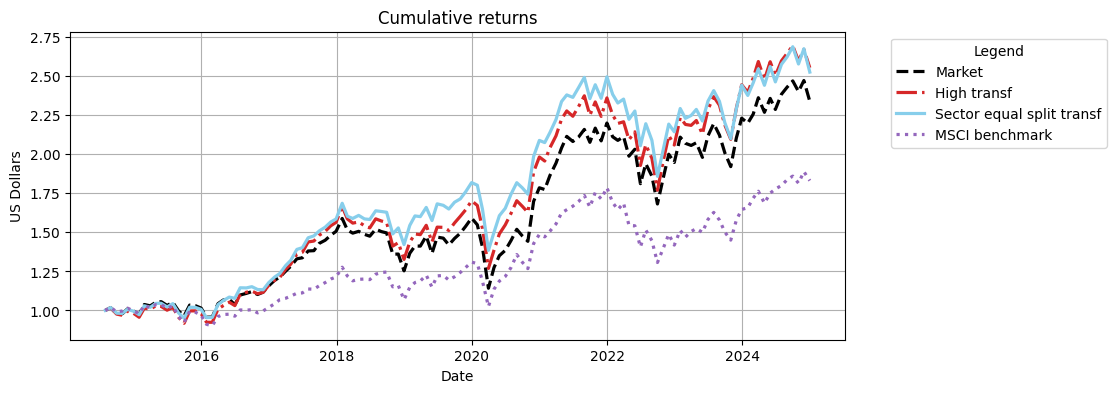

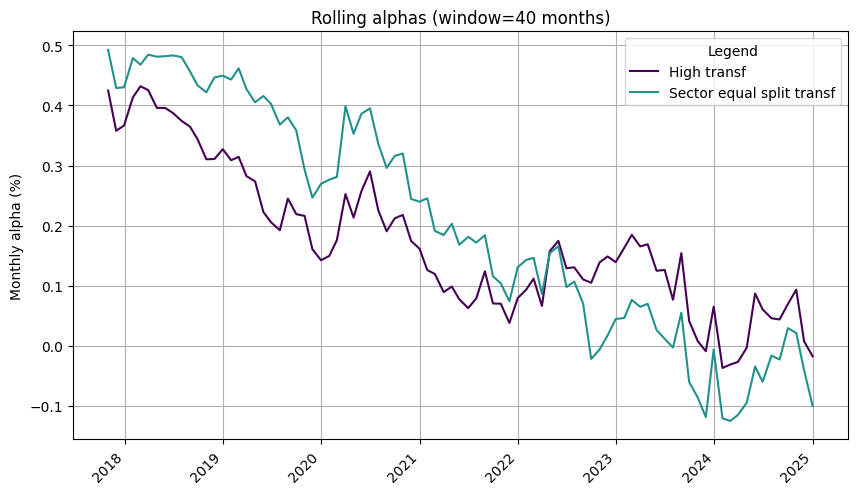

,1m,3m,YTD,1yr,3yr,5yr,10yr,Since launch
Market,-5.39%,-5.30%,4.82%,4.82%,6.32%,46.93%,134.95%,133.91%
High transf,-4.40%,-5.24%,4.45%,4.45%,8.18%,50.06%,160.27%,155.42%
Sector equal split transf,-5.59%,-6.04%,3.43%,3.43%,1.21%,38.90%,153.94%,152.65%
MSCI benchmark,-3.06%,-1.56%,11.21%,11.21%,2.52%,39.80%,83.63%,83.13%


,Sharpe,VaR 1%,Max Drawdown,Alpha,p-value(alpha)
Market,0.56,-10.54%,-28.25%,,
High transf,0.62,-10.27%,-25.47%,0.19,0.050
Sector equal split transf,0.63,-10.72%,-25.54%,0.20,0.050
MSCI benchmark,0.46,-9.45%,-26.82%,,


<Axes: title={'center': 'Rolling Annualised Sharpe (24-month window)'}, ylabel='Sharpe'>

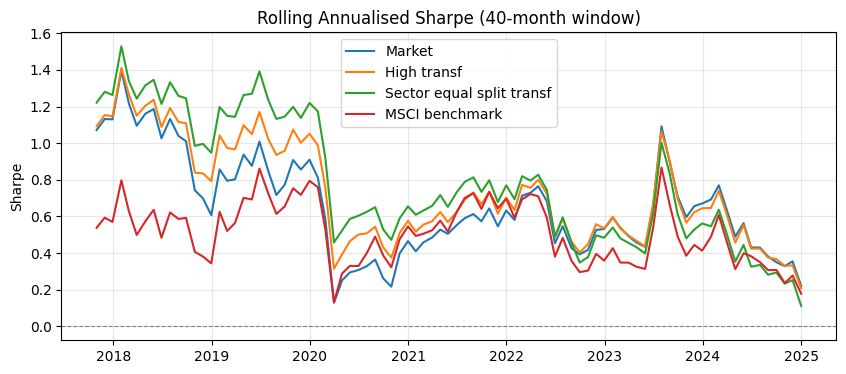

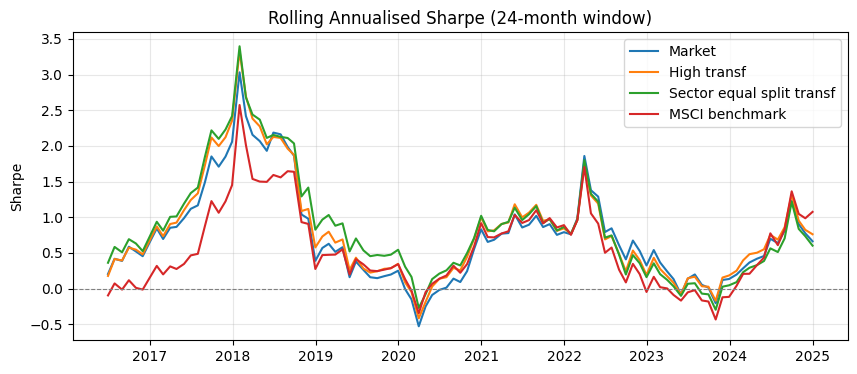

In [ ]:
from functions.Strategy_Perfomance import StrategyPerformance
from functions.fama_french import plot_rolling_alpha_function



start_date = str(portfolio_returns.index[0])[:7]
end_date = str(portfolio_returns.index[-1])[:7]

sp = StrategyPerformance(portfolio_returns, ff3_parts_df=ff3_parts_df)


cumulative_table = sp.cumulative_performance_table(
    csv_path=f"./output/strategy_cumulative_performance_{start_date}-{end_date}.csv")

risk_table = sp.performance_risk_metrics_table(
    csv_path=f"./output/strategy_performance_metrics_{start_date}-{end_date}.csv")



sp.plot_cumulative_returns(
    title="Cumulative returns",
    tight_layout_rect = (0, 5, 100, 0.9),
    save_path=f"./output/img/cumulative_returns_{res_suffix}.png"
)

# Note: sector-split alpha is appended later once `sector_portfolio_returns` exists.
plot_rolling_alpha_function(
    rolling_alphas,
    title="Rolling alphas (window=40 months)",
    save_path="./output/img/rolling_alphas_" + res_suffix + ".png",
)

display(cumulative_table)
display(risk_table)


sp.plot_rolling_sharpe(window=40, save_path=f"./output/img/strategy_rolling_sharpe_40m_{start_date}-{end_date}.png")
#sp.plot_rolling_sharpe(window=60, save_path=f"./output/img/strategy_rolling_sharpe_60m_{start_date}-{end_date}.png")
sp.plot_rolling_sharpe(window=24, save_path=f"./output/img/strategy_rolling_sharpe_24m_{start_date}-{end_date}.png")


# 7. Portfolio Constituents

### Portfolio constituents — category mix (`PortfolioConstituents`)

Uses `signal_2_simple_quantiles_constituents` and `global_universe` to inspect **Industry**, **`loc`**, and **MacroRegion**: line charts of stock counts over time (default = last quantile `p_k`, same as `constituents[i][-1]`) and donut charts for the **final** formation month. Optional: `analyse_all_portfolios_at_once=True` unions all `p_1`…`p_k`; `all_sub_portfolios=True` plots one subplot per quantile.


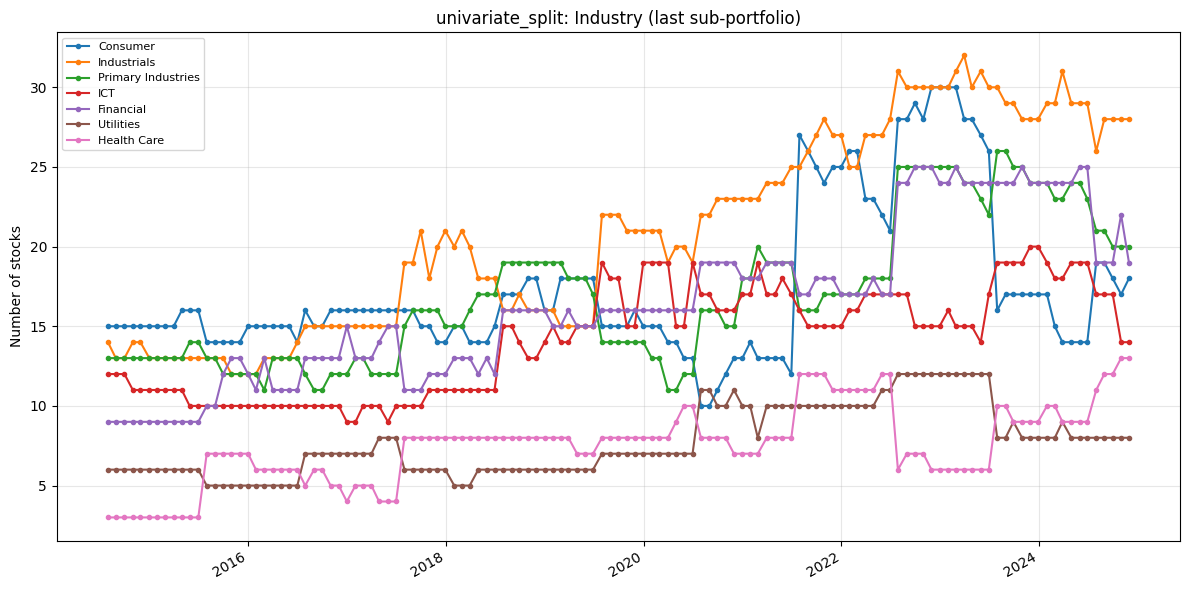

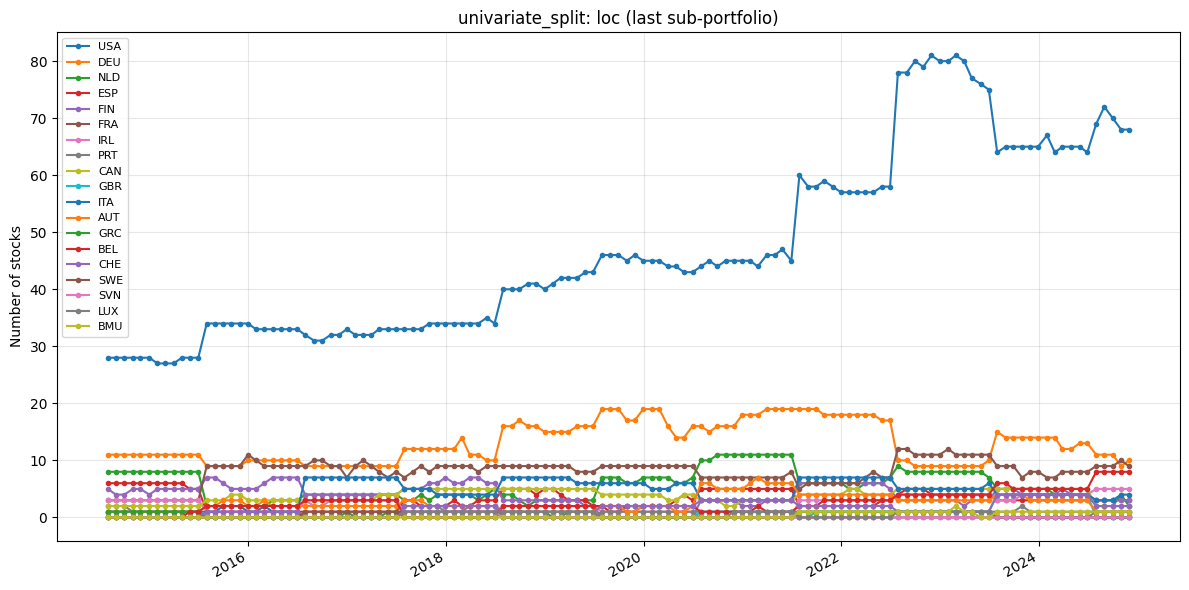

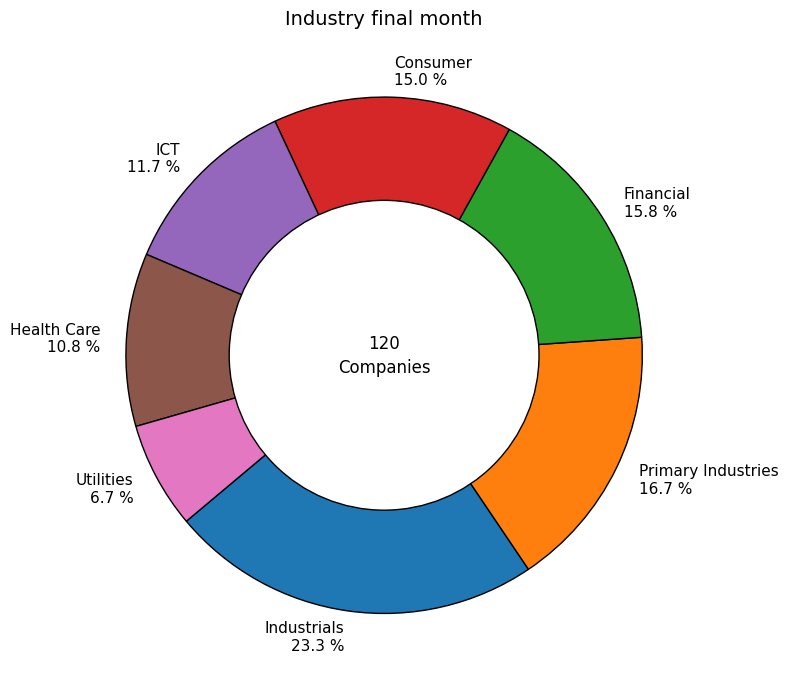

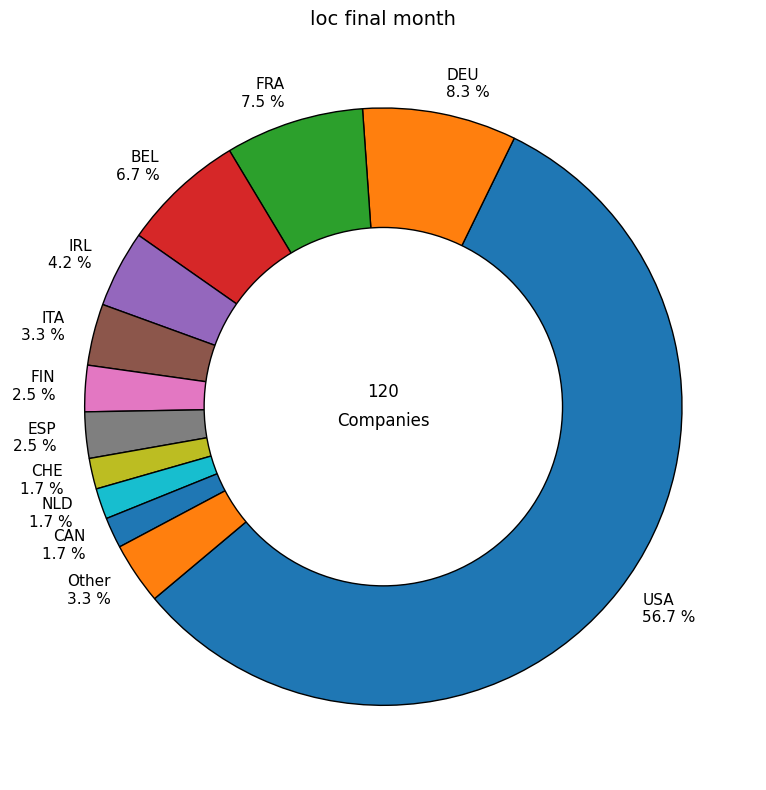

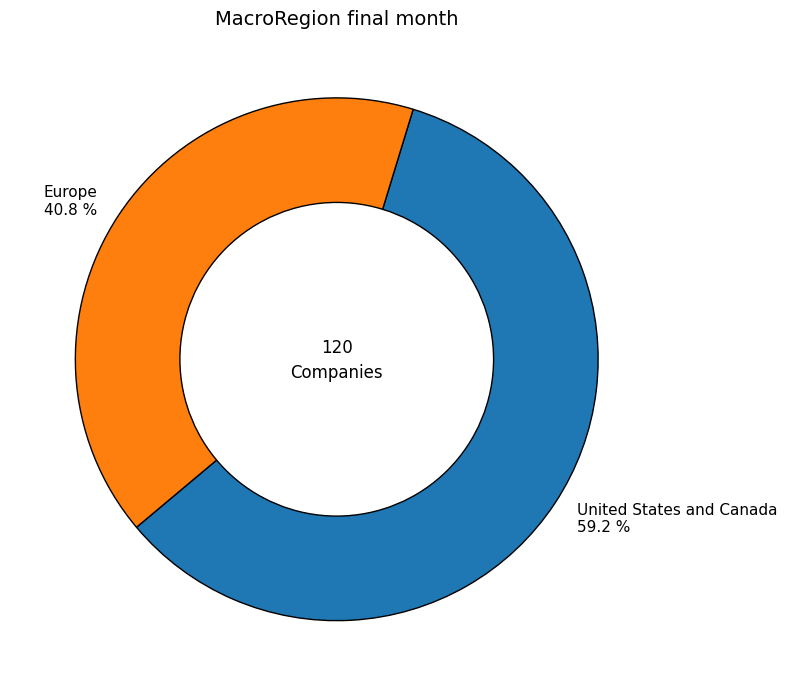

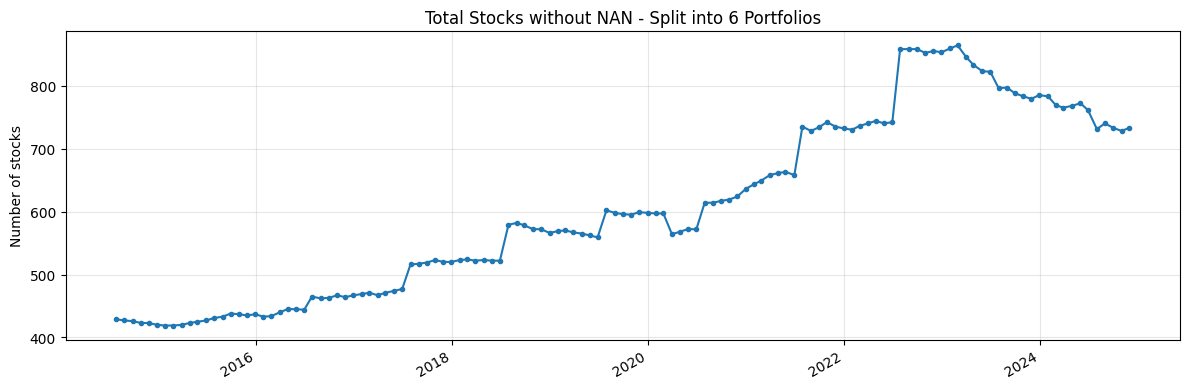

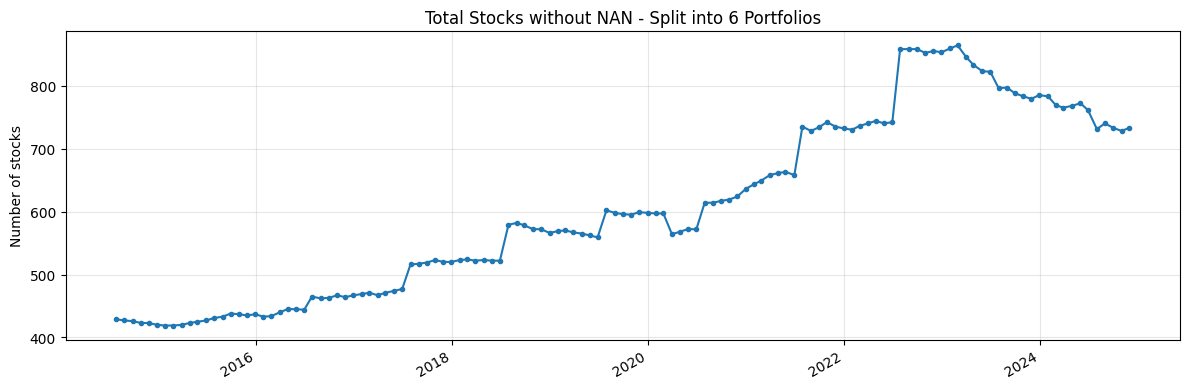

In [ ]:
from IPython.display import display
from functions.Portfolio_Constituents import PortfolioConstituents

pc2 = PortfolioConstituents(
    signal_2_simple_quantiles_constituents,
    global_universe,
    portfolio_type="univariate_split",
)




_dates, wide_industry = pc2._counts_by_category_over_time(
    "Industry",
    portfolio_key=None,  # ignored when analyse_all_portfolios_at_once=True
    analyse_all_portfolios_at_once=False,
)

pc2.run_all_plots(save=True, show=True)

# Options:
#pc2.run_all_plots(analyse_all_portfolios_at_once=True, save=True, show=True)
#pc2.run_all_plots(all_sub_portfolios=True, save=True, show=True)
# Plot (like your snippet)
pc2.total_stocks_over_time(title=f"Total Stocks without NAN - Split into {no_simple_quantiles} Portfolios")
